In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

C:\Users\Sei\anaconda3\envs\tf\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
IMAGE_SIZE = 224
BATCH_SIZE = 100
#construct instance of ImageDataGenerator class
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    zoom_range=0.2,         
    width_shift_range=0.1,   
    height_shift_range=0.1,
    rotation_range=20,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1.0/255,
    zoom_range=0.2,          
    width_shift_range=0.1,  
    height_shift_range=0.1,
    rotation_range=20,
    horizontal_flip=True
)

In [3]:
model = keras.Sequential()

#Defining CNN Layers ( modify Activation here for experimentation <3 )

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMAGE_SIZE,IMAGE_SIZE,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(2, activation='softmax'))

C:\Users\Sei\anaconda3\envs\tf\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
#prepare iterators to loop through each image
training_iterator = train_datagen.flow_from_directory(
    'melanoma_cancer_dataset/train',
    batch_size=BATCH_SIZE,
    target_size=(IMAGE_SIZE, IMAGE_SIZE)
)

testing_iterator = test_datagen.flow_from_directory(
    'melanoma_cancer_dataset/test',
    batch_size=BATCH_SIZE,
    target_size=(IMAGE_SIZE, IMAGE_SIZE)
)

Found 9605 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [5]:
#compile and fit the model
# CHANGE OPTIMIZER HERE <3
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')
history = model.fit(training_iterator, validation_data = testing_iterator, epochs=5)

C:\Users\Sei\anaconda3\envs\tf\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.7212 - loss: 0.6479 - val_accuracy: 0.8440 - val_loss: 0.3386
Epoch 2/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.8621 - loss: 0.3245 - val_accuracy: 0.8680 - val_loss: 0.3054
Epoch 3/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.8710 - loss: 0.3125 - val_accuracy: 0.8910 - val_loss: 0.2662
Epoch 4/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.8832 - loss: 0.2825 - val_accuracy: 0.8860 - val_loss: 0.2770
Epoch 5/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.8877 - loss: 0.2711 - val_accuracy: 0.8860 - val_loss: 0.2683


In [13]:
#save model
model.save('melanoma_cancer_data_BASE.keras')

# MODEL EVALUATION

In [14]:
model.evaluate(testing_iterator)

10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 1000ms/step - accuracy: 0.8960 - loss: 0.2540


[0.25399982929229736, 0.8960000276565552]

In [15]:
#get class labels from iterator
labels = training_iterator.class_indices
print(labels)

{'benign': 0, 'malignant': 1}


# CONFUSION MATRIX AND GRAPHS

In [16]:
# Confusion matrix and Classification Report

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# 1. Reset the iterator to the beginning of the dataset
testing_iterator.reset() 

# 2. Get the model predictions
# Use verbose=1 to see progress, if desired
preds = model.predict(testing_iterator, steps=len(testing_iterator), verbose=1)

# 3. Determine the predicted labels (index with the highest probability)
predicted_labels = np.argmax(preds, axis=1)

# 4. Get the true labels. We need to ensure we only get as many true labels
# as there are predictions, which is handled by the iterator's internal order.
true_labels = testing_iterator.classes
# Since flow_from_directory iterates over the data in sorted order, 
# and we reset it, we slice the classes array to match the prediction length.
true_labels_sliced = true_labels[:len(predicted_labels)]

# 5. Confusion Matrix
cm = confusion_matrix(true_labels_sliced, predicted_labels)
print("\n--- Confusion Matrix ---")
print(cm)

# 6. Detailed Precision/Recall/F1 Report
# You need the actual class names for the report, not just indices
target_names = list(testing_iterator.class_indices.keys())
print("\n--- Classification Report ---")
print(classification_report(true_labels_sliced, predicted_labels, target_names=target_names))

10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 999ms/step

--- Confusion Matrix ---
[[268 232]
 [251 249]]

--- Classification Report ---
              precision    recall  f1-score   support

      benign       0.52      0.54      0.53       500
   malignant       0.52      0.50      0.51       500

    accuracy                           0.52      1000
   macro avg       0.52      0.52      0.52      1000
weighted avg       0.52      0.52      0.52      1000



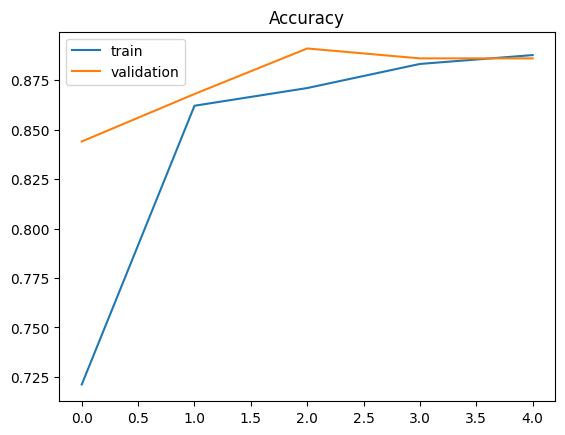

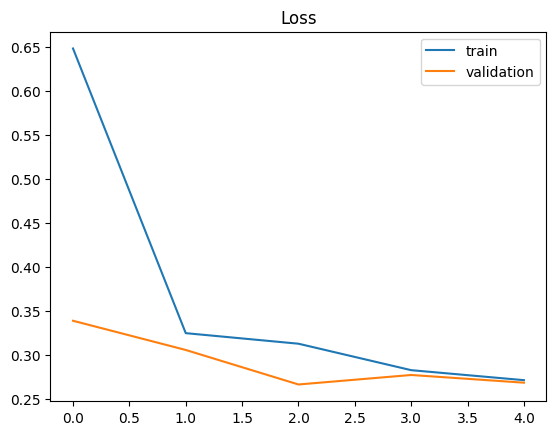

In [20]:
#Accuracy and loss curves
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['train', 'validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['train', 'validation'])
plt.show()


In [19]:
# Test the model's effectiveness on the unseen test data
print("Evaluating model on test data...")
loss, accuracy = model.evaluate(testing_iterator)

# Print the results clearly
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Evaluating model on test data...
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8910 - loss: 0.2650
Test Loss: 0.2650
Test Accuracy: 0.8910


# THIS SECTION EXISTS TO TEST INDIVIDUAL IMAGES 1 BY 1.  Grab anywhere from the internet or in the existing data set

In [22]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array

# --- Configuration ---
# ⚠️ Make sure the file extension (.jpg, .png, etc.) is correct
test_image_path = 'C:/Users/Sei/melanoma_cancer_dataset/train/malignant/melanoma_5002.jpg' 
IMAGE_SIZE = 224 # Must match the size used in model training

# Assuming your training iterator found these classes:
# You can get this by running: print(training_iterator.class_indices)
class_labels = {'benign': 0, 'malignant': 1} 
idx_to_label = {v: k for k, v in class_labels.items()}
# ---------------------

# 1. Load and Resize the Image
img = load_img(test_image_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))

# 2. Convert to Array and Preprocess
img_array = img_to_array(img)

# Expand dimensions to create a batch of 1 (shape: 1, 224, 224, 3)
img_array = np.expand_dims(img_array, axis=0) 

# Rescale the pixel values (divide by 255.0)
img_array = img_array / 255.0

# 3. Make the Prediction
predictions = model.predict(img_array)
probabilities = predictions[0] # Get the probabilities for the single image

# 4. Interpret the Result
predicted_class_index = np.argmax(probabilities)
predicted_label = idx_to_label[predicted_class_index]
confidence = probabilities[predicted_class_index] * 100

print(f"\n--- Prediction Result for {test_image_path.split('/')[-1]} ---")
print(f"The model predicts this image is: **{predicted_label}**")
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

--- Prediction Result for melanoma_5002.jpg ---
The model predicts this image is: **malignant**
Confidence: 99.96%
